# DL_01 - Clasificador IDH: SegResNet BraTS23


- Usa `labels_idh.csv`
- Usa el MISMO hold-out que ML para comparacion directa
- Construye el split directamente desde las carpetas del proyecto
- Guarda modelos en `SS_PIPELINE/dl_clasificador_v2/segresnet/`

**Nombres de archivos stripped:**
- T1   : `{sid}_T1_stripped.nii.gz`
- T1GD : `{sid}_T1GD_stripped.nii.gz`
- T2   : `{sid}_T2_stripped.nii.gz`
- FLAIR: `{sid}_FLAIR_stripped.nii.gz`
- Mask : `{sid}__seg.nii.gz`

In [ ]:
# CELDA 1 - Instalacion de dependencias
!pip install monai[all] nibabel numpy pandas torch torchvision scikit-learn matplotlib seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5

In [ ]:
# CELDA 2 - Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CELDA 3 - Imports y configuracion global
import json
import warnings
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
import nibabel as nib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    matthews_corrcoef, roc_curve, recall_score, accuracy_score,
)
from sklearn.model_selection import train_test_split
from monai.bundle import load
from monai.transforms import (
    RandFlipd, RandRotate90d, RandGaussianNoised, RandZoomd, Compose,
)

warnings.filterwarnings('ignore')

BASE_DRIVE  = Path('/content/drive/MyDrive/GBM_TESIS')
SS_DIR      = BASE_DRIVE / 'SS_PIPELINE'
STRIPPED    = SS_DIR / 'stripped_images'
PRED_DIR    = SS_DIR / 'predictions'
BUNDLE_PATH = BASE_DRIVE / 'MODELO PREENTRENADO/models/brats_mri_segmentation'


DL_DIR     = SS_DIR / 'dl_clasificador_v2'
DL_SEG_DIR = DL_DIR / 'segresnet'
for d in [DL_DIR, DL_SEG_DIR,
          DL_SEG_DIR / 'models',
          DL_SEG_DIR / 'results',
          DL_SEG_DIR / 'figures']:
    d.mkdir(parents=True, exist_ok=True)

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CROP_SIZE    = (64, 64, 64)
BATCH_SIZE   = 8
N_EPOCHS     = 100
LR           = 1e-3
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)

print(f'Dispositivo : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    print(f'VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'CROP_SIZE   : {CROP_SIZE}')
print(f'BATCH_SIZE  : {BATCH_SIZE}')
print(f'\nVerificando rutas:')
print(f'  STRIPPED       : {"✅" if STRIPPED.exists() else "❌"}')
print(f'  PRED_DIR       : {"✅" if PRED_DIR.exists() else "❌"}')
print(f'  BUNDLE_PATH    : {"✅" if BUNDLE_PATH.exists() else "❌"}')
print(f'  Labels         : {"✅" if (BASE_DRIVE / "Dataset/labels_idh_corregido.csv").exists() else "❌"}')
print(f'  Hold-out ML v2 : {"✅" if (SS_DIR / "clasificador_v2/results/holdout_ids.csv").exists() else "❌"}')

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Dispositivo : cuda
GPU         : NVIDIA A100-SXM4-40GB
VRAM        : 42.4 GB
CROP_SIZE   : (64, 64, 64)
BATCH_SIZE  : 8

Verificando rutas:
  STRIPPED       : ✅
  PRED_DIR       : ✅
  BUNDLE_PATH    : ✅
  Labels         : ✅
  Hold-out ML v2 : ✅


In [ ]:
# CELDA 4 - Construir dataset y splits

labels_path = BASE_DRIVE / 'Dataset/labels_idh_corregido.csv'
df_labels   = pd.read_csv(str(labels_path), sep=';')
df_labels.columns = df_labels.columns.str.strip()
df_labels['IDH'] = (df_labels['idh_status'] == 'mutado').astype(int)

print(f'Labels cargados: {len(df_labels)} casos')
print(df_labels['idh_status'].value_counts())

# Construir rutas con nombres correctos
registros    = []
sin_archivos = []
for _, row in df_labels.iterrows():
    sid   = row['caso']
    label = int(row['IDH'])
    strip_dir = STRIPPED / sid

    t1    = strip_dir / f'{sid}_T1_stripped.nii.gz'
    t1ce  = strip_dir / f'{sid}_T1GD_stripped.nii.gz'
    t2    = strip_dir / f'{sid}_T2_stripped.nii.gz'
    flair = strip_dir / f'{sid}_FLAIR_stripped.nii.gz'
    mask  = PRED_DIR  / sid / f'{sid}__seg.nii.gz'

    if all(f.exists() for f in [t1, t1ce, t2, flair, mask]):
        registros.append({
            'sid'      : sid,
            'IDH'      : label,
            't1'       : str(t1),
            't1ce'     : str(t1ce),
            't2'       : str(t2),
            'flair'    : str(flair),
            'mask_path': str(mask),
        })
    else:
        sin_archivos.append(sid)

df_all = pd.DataFrame(registros)
print(f'\nCasos disponibles : {len(df_all)}')
print(f'  Wildtype        : {(df_all["IDH"]==0).sum()}')
print(f'  Mutado          : {(df_all["IDH"]==1).sum()}')
print(f'Sin archivos      : {len(sin_archivos)}')

# Mismo hold-out que ML
holdout_ml_path = SS_DIR / 'clasificador_v2/results/holdout_ids.csv'
df_holdout_ml   = pd.read_csv(str(holdout_ml_path))
ids_holdout_ml  = df_holdout_ml['subject_id'].tolist()

df_hold = df_all[df_all['sid'].isin(ids_holdout_ml)].copy()
df_dev  = df_all[~df_all['sid'].isin(ids_holdout_ml)].copy()

df_train, df_val = train_test_split(
    df_dev, test_size=0.20,
    stratify=df_dev['IDH'],
    random_state=RANDOM_STATE)

print(f'\nDistribucion:')
print(f'  Train  : {len(df_train)} ({(df_train["IDH"]==1).sum()} mut, {(df_train["IDH"]==0).sum()} wt)')
print(f'  Val    : {len(df_val)} ({(df_val["IDH"]==1).sum()} mut, {(df_val["IDH"]==0).sum()} wt)')
print(f'  Holdout: {len(df_hold)} ({(df_hold["IDH"]==1).sum()} mut, {(df_hold["IDH"]==0).sum()} wt)')

# Guardar splits
df_train.to_csv(str(DL_DIR / 'dl_train_ids.csv'), index=False)
df_val.to_csv(str(DL_DIR / 'dl_val_ids.csv'), index=False)
df_hold.to_csv(str(DL_DIR / 'dl_holdout_ids.csv'), index=False)
print('Splits guardados.')

Labels cargados: 527 casos
idh_status
wildtype    458
mutado       69
Name: count, dtype: int64

Casos disponibles : 527
  Wildtype        : 458
  Mutado          : 69
Sin archivos      : 0

Distribucion:
  Train  : 336 (44 mut, 292 wt)
  Val    : 85 (11 mut, 74 wt)
  Holdout: 106 (14 mut, 92 wt)
Splits guardados.


In [ ]:
# CELDA 5 - Preprocesamiento y Dataset

def normalize_volume(vol: np.ndarray) -> np.ndarray:
    nonzero = vol[vol > 0]
    if len(nonzero) == 0:
        return vol
    return (vol - nonzero.mean()) / (nonzero.std() + 1e-8)


def crop_to_tumor(img: np.ndarray, mask: np.ndarray,
                  crop_size: Tuple = CROP_SIZE) -> np.ndarray:
    coords = np.where(mask > 0)
    if len(coords[0]) > 0:
        center = [int(np.mean(c)) for c in coords]
    else:
        center = [s // 2 for s in img.shape[:3]]
    slices = []
    for i, (c, s) in enumerate(zip(center, img.shape[:3])):
        half  = crop_size[i] // 2
        start = max(0, c - half)
        end   = min(s, start + crop_size[i])
        start = max(0, end - crop_size[i])
        slices.append(slice(start, end))
    cropped   = img[slices[0], slices[1], slices[2]]
    pad_width = [(0, max(0, crop_size[i] - cropped.shape[i])) for i in range(3)]
    return np.pad(cropped, pad_width, mode='constant', constant_values=0)


aug_strong = Compose([
    RandFlipd(keys=['img'], prob=0.5, spatial_axis=0),
    RandFlipd(keys=['img'], prob=0.5, spatial_axis=1),
    RandFlipd(keys=['img'], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=['img'], prob=0.5, max_k=3, spatial_axes=(0, 1)),
    RandGaussianNoised(keys=['img'], prob=0.3, mean=0.0, std=0.1),
    RandZoomd(keys=['img'], prob=0.3, min_zoom=0.85, max_zoom=1.15, mode='trilinear'),
])

aug_mild = Compose([
    RandFlipd(keys=['img'], prob=0.5, spatial_axis=0),
    RandFlipd(keys=['img'], prob=0.5, spatial_axis=2),
    RandGaussianNoised(keys=['img'], prob=0.2, mean=0.0, std=0.05),
])


class IDHDatasetSegResNet(Dataset):
    def __init__(self, df: pd.DataFrame, augment: bool = False):
        self.df      = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row   = self.df.iloc[idx]
        label = int(row['IDH'])
        mask  = nib.load(str(row['mask_path'])).get_fdata().astype(np.uint8)

        vols = []
        for mod in ['t1', 't1ce', 't2', 'flair']:
            vol = nib.load(str(row[mod])).get_fdata().astype(np.float32)
            vol = normalize_volume(vol)
            vol = crop_to_tumor(vol, mask)
            vols.append(vol)

        img = np.stack(vols, axis=-1)  # (64, 64, 64, 4)

        if self.augment:
            tfm = aug_strong if label == 1 else aug_mild
            img = tfm({'img': img})['img']

        img = torch.tensor(
            img if isinstance(img, np.ndarray) else np.array(img),
            dtype=torch.float32
        ).permute(3, 0, 1, 2)  # (4, 64, 64, 64)

        return img, torch.tensor(label, dtype=torch.float32)


print('Preprocesamiento y Dataset definidos.')
print(f'Tensor de entrada por muestra: (4, {CROP_SIZE[0]}, {CROP_SIZE[1]}, {CROP_SIZE[2]})')

Preprocesamiento y Dataset definidos.
Tensor de entrada por muestra: (4, 64, 64, 64)


In [ ]:
# CELDA 6 - Modelo SegResNetClassifier

class SegResNetClassifier(nn.Module):
    def __init__(self, bundle_path: Path, dropout: float = 0.5):
        super().__init__()
        backbone         = load(name=str(bundle_path), source='disk', net_override={})
        self.conv_init   = backbone.convInit
        self.down_layers = backbone.down_layers

        # Encoder completamente congelado
        for param in self.conv_init.parameters():
            param.requires_grad = False
        for param in self.down_layers.parameters():
            param.requires_grad = False

        self.gap = nn.AdaptiveAvgPool3d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_init(x)
        for layer in self.down_layers:
            x = layer(x)
        x = self.gap(x)
        return self.classifier(x)


model = SegResNetClassifier(BUNDLE_PATH, dropout=0.5)
n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametros totales    : {n_total:,}')
print(f'Parametros entrenables: {n_trainable:,} ({100*n_trainable/n_total:.1f}%)')

# Verificar forma del tensor
model.eval()
model.to('cpu')
with torch.no_grad():
    dummy = torch.zeros(1, 4, *CROP_SIZE)
    x_enc = model.conv_init(dummy)
    for layer in model.down_layers:
        x_enc = layer(x_enc)
    print(f'Forma bottleneck (batch=1): {tuple(x_enc.shape)}')
    print(f'Tras GAP                 : (1, {x_enc.shape[1]}, 1, 1, 1)')

2026-04-24 01:26:33,100 - INFO - Setting logging properties based on config: /content/drive/MyDrive/GBM_TESIS/MODELO PREENTRENADO/models/brats_mri_segmentation/configs/logging.conf.
2026-04-24 01:26:33,691 - INFO - --- input summary of monai.bundle.scripts.run ---
2026-04-24 01:26:33,692 - INFO - > workflow_type: 'train'
2026-04-24 01:26:33,692 - INFO - ---


2026-04-24 01:26:33,777 - INFO - 'dst' model updated: 83 of 83 variables.
Parametros totales    : 4,404,801
Parametros entrenables: 4,161 (0.1%)
Forma bottleneck (batch=1): (1, 128, 8, 8, 8)
Tras GAP                 : (1, 128, 1, 1, 1)


In [ ]:
# CELDA 7 - DataLoaders

def build_weighted_sampler(labels: List[int]) -> WeightedRandomSampler:
    labels_arr = np.array(labels)
    n_mut  = (labels_arr == 1).sum()
    n_wt   = (labels_arr == 0).sum()
    weights = np.where(labels_arr == 1, 1.0 / n_mut, 1.0 / n_wt)
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True,
    )


ds_train = IDHDatasetSegResNet(df_train, augment=True)
ds_val   = IDHDatasetSegResNet(df_val,   augment=False)
ds_hold  = IDHDatasetSegResNet(df_hold,  augment=False)

sampler = build_weighted_sampler(df_train['IDH'].tolist())

loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=2, pin_memory=True)
loader_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)
loader_hold  = DataLoader(ds_hold,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

n_mutado   = int((df_train['IDH'] == 1).sum())
n_wildtype = int((df_train['IDH'] == 0).sum())
pos_weight = min(n_wildtype / n_mutado, 3.0)

print(f'Train  : {len(ds_train)} casos')
print(f'Val    : {len(ds_val)} casos')
print(f'Holdout: {len(ds_hold)} casos (mismo que ML)')
print(f'Batches por epoca : {len(loader_train)}')
print(f'pos_weight BCE    : {pos_weight:.2f}')

Train  : 336 casos
Val    : 85 casos
Holdout: 106 casos (mismo que ML)
Batches por epoca : 42
pos_weight BCE    : 3.00


In [ ]:
# CELDA 8 - Funciones de entrenamiento

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= 0.5).astype(int)
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), auc, acc


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.to(device).unsqueeze(1)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item()
        all_probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds  = (all_probs >= 0.5).astype(int)
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), auc, acc, all_probs, all_labels


print('Funciones de entrenamiento definidas.')

Funciones de entrenamiento definidas.


In [ ]:
# CELDA 9 - Entrenamiento

model.to(DEVICE)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight]).to(DEVICE)
)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-2,
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS, eta_min=1e-5
)

history = {
    'train_loss': [], 'train_auc': [], 'train_acc': [],
    'val_loss':   [], 'val_auc':   [], 'val_acc':   [],
}
best_auc = 0.0

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_auc, tr_acc          = train_epoch(model, loader_train, optimizer, criterion, DEVICE)
    val_loss, val_auc, val_acc, _, _ = eval_epoch(model, loader_val, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_auc'].append(tr_auc)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    history['val_acc'].append(val_acc)

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(),
                   str(DL_SEG_DIR / 'models/segresnet_best.pth'))

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | '
              f'Train Loss={tr_loss:.4f} AUC={tr_auc:.4f} Acc={tr_acc:.4f} | '
              f'Val Loss={val_loss:.4f} AUC={val_auc:.4f} Acc={val_acc:.4f}')

# Guardar historial de entrenamiento
with open(DL_SEG_DIR / 'results/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print('✅ Historial de entrenamiento guardado.')
print(f'\nMejor Val AUC: {best_auc:.4f}')
print(f'Modelo guardado en: {DL_SEG_DIR}/models/segresnet_best.pth')

Epoch   1/100 | Train Loss=1.5078 AUC=0.5502 Acc=0.5149 | Val Loss=1.1874 AUC=0.6290 Acc=0.1294
Epoch  10/100 | Train Loss=1.0894 AUC=0.6752 Acc=0.4643 | Val Loss=1.0865 AUC=0.6953 Acc=0.1529
Epoch  20/100 | Train Loss=1.0611 AUC=0.6818 Acc=0.5506 | Val Loss=1.2085 AUC=0.7764 Acc=0.1294
Epoch  30/100 | Train Loss=1.0217 AUC=0.7111 Acc=0.5625 | Val Loss=1.0216 AUC=0.7604 Acc=0.2471
Epoch  40/100 | Train Loss=1.0159 AUC=0.7145 Acc=0.5804 | Val Loss=1.1659 AUC=0.7875 Acc=0.1882
Epoch  50/100 | Train Loss=0.8804 AUC=0.8146 Acc=0.6071 | Val Loss=0.9801 AUC=0.7850 Acc=0.3765
Epoch  60/100 | Train Loss=0.8813 AUC=0.7915 Acc=0.6815 | Val Loss=1.2673 AUC=0.7580 Acc=0.2235
Epoch  70/100 | Train Loss=0.9163 AUC=0.8032 Acc=0.5833 | Val Loss=0.9311 AUC=0.7961 Acc=0.3882
Epoch  80/100 | Train Loss=0.8667 AUC=0.8283 Acc=0.6429 | Val Loss=0.9684 AUC=0.7961 Acc=0.3412
Epoch  90/100 | Train Loss=0.8765 AUC=0.8129 Acc=0.6696 | Val Loss=1.0607 AUC=0.7850 Acc=0.2824
Epoch 100/100 | Train Loss=0.8780 AUC=0.

In [ ]:
# CELDA 10 - Umbral optimo sobre validacion (Youden)

model.load_state_dict(torch.load(
    str(DL_SEG_DIR / 'models/segresnet_best.pth'), map_location=DEVICE
))

_, _, _, probs_val, labels_val = eval_epoch(model, loader_val, criterion, DEVICE)

fpr_val, tpr_val, thresholds_val = roc_curve(labels_val, probs_val)
youden    = tpr_val - fpr_val
idx_opt   = np.argmax(youden)
THRESHOLD = float(thresholds_val[idx_opt])

print(f'Umbral optimo (validacion): {THRESHOLD:.4f}')
print(f'  Sensitivity val: {tpr_val[idx_opt]:.4f}')
print(f'  Specificity val: {1 - fpr_val[idx_opt]:.4f}')

Umbral optimo (validacion): 0.6915
  Sensitivity val: 0.8182
  Specificity val: 0.7568


In [ ]:
# CELDA 11 - Evaluacion en hold-out (mismo que ML)

_, _, _, probs, labels = eval_epoch(model, loader_hold, criterion, DEVICE)
preds = (probs >= THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
spec = tn / (tn + fp + 1e-8)

metrics = {
    'auc'        : float(roc_auc_score(labels, probs)),
    'f1'         : float(f1_score(labels, preds)),
    'accuracy'   : float(accuracy_score(labels, preds)),
    'sensitivity': float(recall_score(labels, preds)),
    'specificity': float(spec),
    'mcc'        : float(matthews_corrcoef(labels, preds)),
    'threshold'  : THRESHOLD,
    'tp': int(tp), 'fp': int(fp), 'tn': int(tn), 'fn': int(fn),
}

with open(DL_SEG_DIR / 'results/holdout_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Metricas hold-out - SegResNet BraTS23 (mismo hold-out que ML):')
print(f'  Casos hold-out  : {len(labels)} (mismo que ML)')
print(f'  Umbral          : {THRESHOLD:.4f}')
print(f'  AUC-ROC         : {metrics["auc"]:.4f}')
print(f'  F1-Score        : {metrics["f1"]:.4f}')
print(f'  Sensitivity     : {metrics["sensitivity"]:.4f}')
print(f'  Specificity     : {metrics["specificity"]:.4f}')
print(f'  MCC             : {metrics["mcc"]:.4f}')
print(f'  TP={tp} FP={fp} TN={tn} FN={fn}')

Metricas hold-out - SegResNet BraTS23 (mismo hold-out que ML):
  Casos hold-out  : 106 (mismo que ML)
  Umbral          : 0.6915
  AUC-ROC         : 0.8012
  F1-Score        : 0.4706
  Sensitivity     : 0.8571
  Specificity     : 0.7283
  MCC             : 0.4158
  TP=12 FP=25 TN=67 FN=2


In [ ]:
# CELDA 12 - Curvas de entrenamiento desde historial guardadoimport matplotlib.pyplot as plt
import json
from pathlib import Path

DL_SEG_DIR = Path('/content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/dl_clasificador_v2/segresnet')

# Leer historial guardado por la celda de entrenamiento
with open(DL_SEG_DIR / 'results/training_history.json') as f:
    h = json.load(f)

epochs_log = list(range(1, len(h['train_loss']) + 1))
train_loss = h['train_loss']
val_loss   = h['val_loss']
train_auc  = h['train_auc']
val_auc    = h['val_auc']
train_acc  = h['train_acc']
val_acc    = h['val_acc']

color_train = '#7F77DD'
color_val   = '#D85A30'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(epochs_log, train_loss, label='Train', color=color_train, lw=2)
axes[0].plot(epochs_log, val_loss,   label='Val',   color=color_val,   lw=2, ls='--')
axes[0].set_title('Loss (BCE)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_log, train_auc, label='Train', color=color_train, lw=2)
axes[1].plot(epochs_log, val_auc,   label='Val',   color=color_val,   lw=2, ls='--')
axes[1].set_title('AUC-ROC')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(epochs_log, train_acc, label='Train', color=color_train, lw=2)
axes[2].plot(epochs_log, val_acc,   label='Val',   color=color_val,   lw=2, ls='--')
axes[2].set_title('Accuracy')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('SegResNet BraTS23 - Curvas de Entrenamiento', fontsize=13)
plt.tight_layout()
plt.savefig(str(DL_SEG_DIR / 'figures/segresnet_entrenamiento_v2.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Gráficas guardadas.')

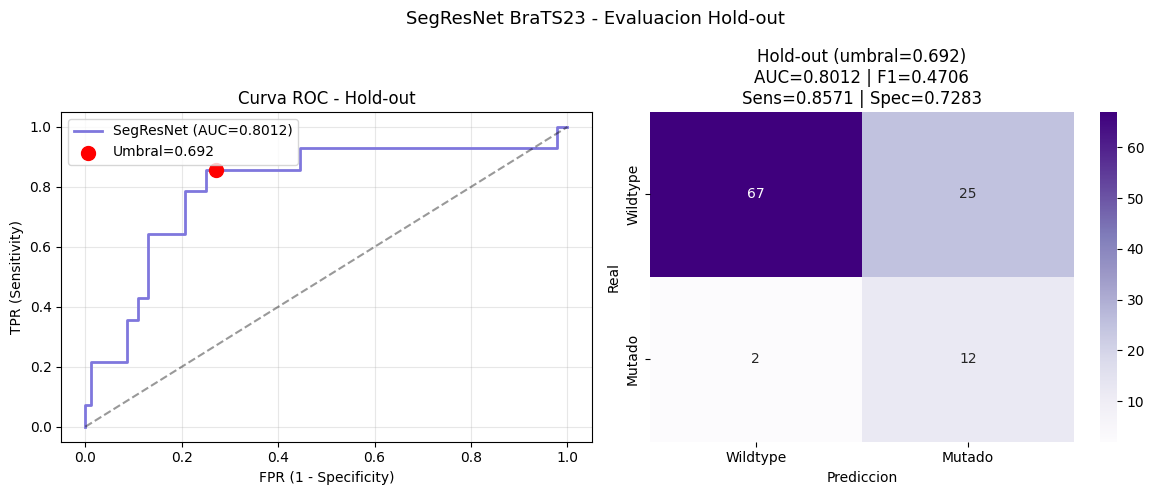

Figura guardada.


In [ ]:
# CELDA 13 - Figuras hold-out

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
color = '#7F77DD'

fpr_h, tpr_h, _ = roc_curve(labels, probs)
axes[0].plot(fpr_h, tpr_h, color=color, lw=2,
             label=f'SegResNet (AUC={metrics["auc"]:.4f})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.4)
axes[0].scatter([1-metrics['specificity']], [metrics['sensitivity']],
                color='red', s=100, zorder=5,
                label=f'Umbral={THRESHOLD:.3f}')
axes[0].set_xlabel('FPR (1 - Specificity)')
axes[0].set_ylabel('TPR (Sensitivity)')
axes[0].set_title('Curva ROC - Hold-out')
axes[0].legend()
axes[0].grid(alpha=0.3)

cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[1],
            xticklabels=['Wildtype', 'Mutado'],
            yticklabels=['Wildtype', 'Mutado'])
axes[1].set_title(
    f'Hold-out (umbral={THRESHOLD:.3f})\n'
    f'AUC={metrics["auc"]:.4f} | F1={metrics["f1"]:.4f}\n'
    f'Sens={metrics["sensitivity"]:.4f} | Spec={metrics["specificity"]:.4f}')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Prediccion')

plt.suptitle('SegResNet BraTS23 - Evaluacion Hold-out', fontsize=13)
plt.tight_layout()
plt.savefig(DL_SEG_DIR / 'figures/segresnet_holdout_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada.')

In [ ]:
# CELDA 14 - Guardar configuracion

dl_config = {
    'model'            : 'SegResNet BraTS23 v2',
    'n_channels'       : 4,
    'crop_size'        : list(CROP_SIZE),
    'threshold'        : THRESHOLD,
    'labels_version'   : 'labels_idh_corregido.csv',
    'holdout_mismo_ml' : True,
    'weights_path'     : str(DL_SEG_DIR / 'models/segresnet_best.pth'),
    'auc_holdout'      : metrics['auc'],
    'f1_holdout'       : metrics['f1'],
    'accuracy'         : metrics['accuracy'],
    'sensitivity'      : metrics['sensitivity'],
    'specificity'      : metrics['specificity'],
    'mcc'              : metrics['mcc'],
    'n_train'          : len(df_train),
    'n_val'            : len(df_val),
    'n_hold'           : len(df_hold),
}

with open(DL_SEG_DIR / 'segresnet_config_v2.json', 'w') as f:
    json.dump(dl_config, f, indent=2)

print('Configuracion guardada.')
print(f'\nResumen SegResNet BraTS23 (labels corregidos):')
print(f'  Train/Val/Hold : {len(df_train)}/{len(df_val)}/{len(df_hold)}')
print(f'  AUC-ROC        : {metrics["auc"]:.4f}')
print(f'  F1-Score       : {metrics["f1"]:.4f}')
print(f'  Sensitivity    : {metrics["sensitivity"]:.4f}')
print(f'  Specificity    : {metrics["specificity"]:.4f}')
print(f'  MCC            : {metrics["mcc"]:.4f}')

Configuracion guardada.

Resumen SegResNet BraTS23 (labels corregidos):
  Train/Val/Hold : 336/85/106
  AUC-ROC        : 0.8012
  F1-Score       : 0.4706
  Sensitivity    : 0.8571
  Specificity    : 0.7283
  MCC            : 0.4158
